In [50]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import numpy as np
pd.options.mode.chained_assignment = None 

In [51]:
# compare within lang1 <-> lang2 keep baseline vs augmented, model constant
lang_compare = pd.read_csv("among_lang_metrics.csv", index_col=0)

# compare within baseline <-> augmented keep lang, model  constant
baseline_compare = pd.read_csv("between_lang_baseline_metrics.csv", index_col=0)

# compare within gen1 <-> gen2 keep baseline vs augmented, model and lang constant
within_baseline_prompt = pd.read_csv("within_baseline_non_baseline.csv", index_col=0)

# compare within all language pairs baseline vs augmented, keep model constant
compare_all = pd.read_csv("all_comparisons.csv", index_col=0)

In [52]:
lang_compare["Model"] = ["-".join(x.split("-")[:2]) for x in lang_compare["Model"]]
baseline_compare["Model"] = ["-".join(x.split("-")[:2]) for x in baseline_compare["Model"]]
within_baseline_prompt["Model"] = ["-".join(x.split("-")[:2]) for x in within_baseline_prompt["Model"]]
compare_all["Model"] = ["-".join(x.split("-")[:2]) for x in compare_all["Model"]]


In [53]:
models = ['Qwen3-4B', 'Qwen3-30B', 'Qwen3-235B']
metrics = ["Cosine", "Rouge"]
languages = list(baseline_compare["Language"].unique())
lang_pairs = list(lang_compare["Language1-Language2"].unique())
questions = list(lang_compare["Question"].unique())

In [54]:
models

['Qwen3-4B', 'Qwen3-14B', 'Qwen3-30B']

In [55]:
lang_compare.drop("Question", axis=1).groupby(["Model","Language1-Language2", "fBaseline"]).agg(['mean', 'std', 'count'])

Cosine                
                                             mean       std count
Model     Language1-Language2 fBaseline                          
Qwen3-14B EN-FR               False      0.858052  0.054914  1000
                              True       0.867416  0.034506  1000
          EN-NL               False      0.801682  0.099801  1000
                              True       0.854992  0.070812  1000
          FR-NL               False      0.761155  0.091212  1000
                              True       0.805639  0.079403  1000
Qwen3-30B EN-FR               False      0.800562  0.089647  1000
                              True       0.883222  0.030440  1000
          EN-NL               False      0.763015  0.093183  1000
                              True       0.872528  0.050459  1000
          FR-NL               False      0.775018  0.078153  1000
                              True       0.829428  0.054083  1000
Qwen3-4B  EN-FR               False      0.774615  0.077526  1000
                              True       0.878246  0.023768  1000
          EN-NL               False      0.777667  0.101914  1000
                              True       0.859202  0.069251  1000
          FR-NL               False      0.717535  0.090896  1000
                              True       0.833400  0.079633  1000

In [56]:
lang_compare.groupby(["Model","Question","Language1-Language2", "fBaseline"]).agg(['mean', 'std', 'count'])

Cosine                
                                                        mean       std count
Model     Question   Language1-Language2 fBaseline                          
Qwen3-14B Question 1 EN-FR               False      0.862847  0.019355   100
                                         True       0.865481  0.030951   100
                     EN-NL               False      0.826093  0.061765   100
                                         True       0.914193  0.022537   100
                     FR-NL               False      0.739704  0.075307   100
...                                                      ...       ...   ...
Qwen3-4B  Question 9 EN-FR               True       0.883867  0.018122   100
                     EN-NL               False      0.663149  0.032692   100
                                         True       0.908006  0.016500   100
                     FR-NL               False      0.661548  0.030521   100
                                         True       0.881107  0.015927   100

[180 rows x 3 columns]

In [57]:
baseline_compare.drop("Question", axis=1).groupby(["Model", "Language"]).agg(["mean", "count"])

Cosine           Rouge      
                        mean count      mean count
Model     Language                                
Qwen3-14B EN        0.917914  1000  0.343583  1000
          FR        0.917892  1000  0.334740  1000
          NL        0.805660  1000  0.289168  1000
Qwen3-30B EN        0.857426  1000  0.259068  1000
          FR        0.896972  1000  0.267871  1000
          NL        0.812511  1000  0.267764  1000
Qwen3-4B  EN        0.837760  1000  0.236464  1000
          FR        0.790399  1000  0.216529  1000
          NL        0.845943  1000  0.245693  1000

In [58]:
baseline_compare.groupby(["Model", "Question", "Language"]).agg(["mean", "count"])

Cosine           Rouge      
                                    mean count      mean count
Model     Question    Language                                
Qwen3-14B Question 1  EN        0.946255   100  0.439701   100
                      FR        0.958561   100  0.417116   100
                      NL        0.816835   100  0.382627   100
          Question 10 EN        0.953039   100  0.407138   100
                      FR        0.925724   100  0.329564   100
...                                  ...   ...       ...   ...
Qwen3-4B  Question 8  FR        0.702196   100  0.216963   100
                      NL        0.860615   100  0.234448   100
          Question 9  EN        0.689712   100  0.159134   100
                      FR        0.731846   100  0.194974   100
                      NL        0.862580   100  0.232193   100

[90 rows x 4 columns]

In [59]:
# # std in scores between baseline and augmented per language per model
# fig, axs = plt.subplots(ncols=len(models), figsize=(10,5), sharey=False)
# i=0
# for model in models:
#     axs[i].set_title(model + " baseline vs augmented")
#     test = compare_all[compare_all["Model"]==model]
#     # print(test.head())
#     # print(test.head())
#     sns.boxplot(data=test, x="Language1-Language2", y="Cosine", ax=axs[i])
#     axs[i].set_ylim([-0.15, 1.1])
#     i+=1

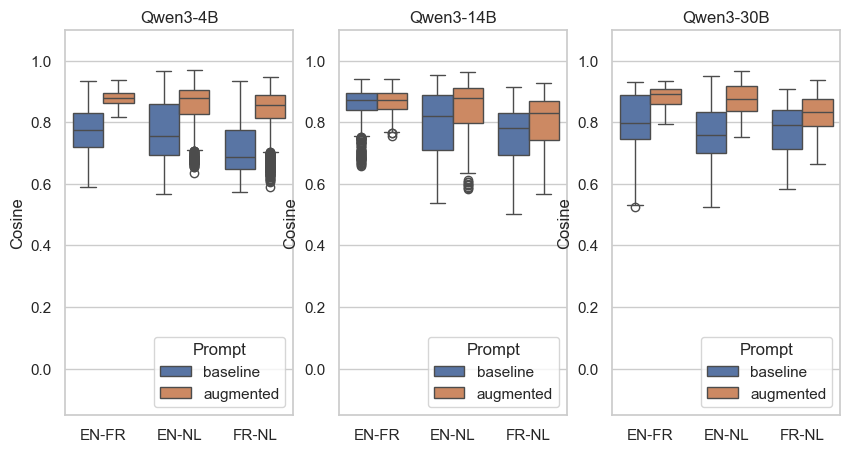

In [60]:
# std in scores amongst baseline condition and amongst augmented conditnion per language pair per model
# when looking at augmented condition, the IQR is smaller in almost all cases,
# mean that bertscore is more consistent -> more similar answers in all language pairs

fig, axs = plt.subplots(ncols=len(models), figsize=(10,5), sharey=False)
i=0
for model in models:
    axs[i].set_title(model)
    axs[i].set_ylim([-0.15, 1.1])
    test = lang_compare[(lang_compare["Model"]==model)]
    test["Prompt"] = ["augmented" if x else "baseline" for x in test["fBaseline"]]
    ax=sns.boxplot(x=test["Language1-Language2"].to_list(), y="Cosine", hue="Prompt", data=test, ax=axs[i])
    sns.move_legend(ax, "lower right")
    i+=1

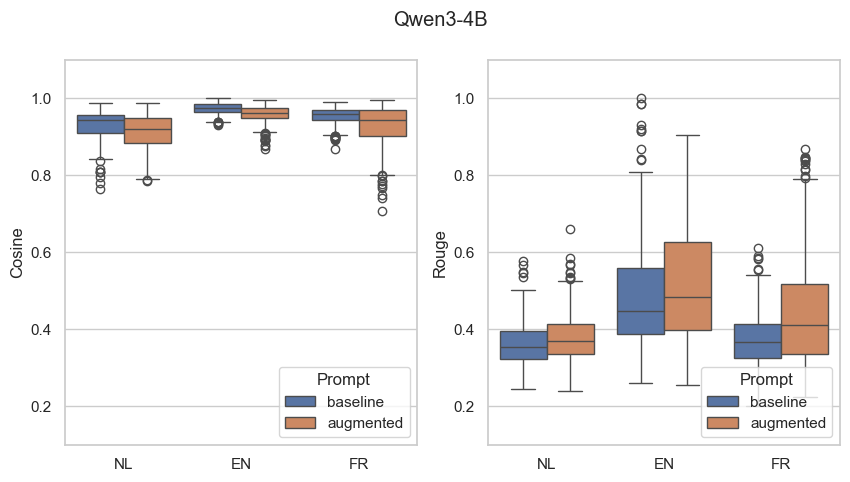

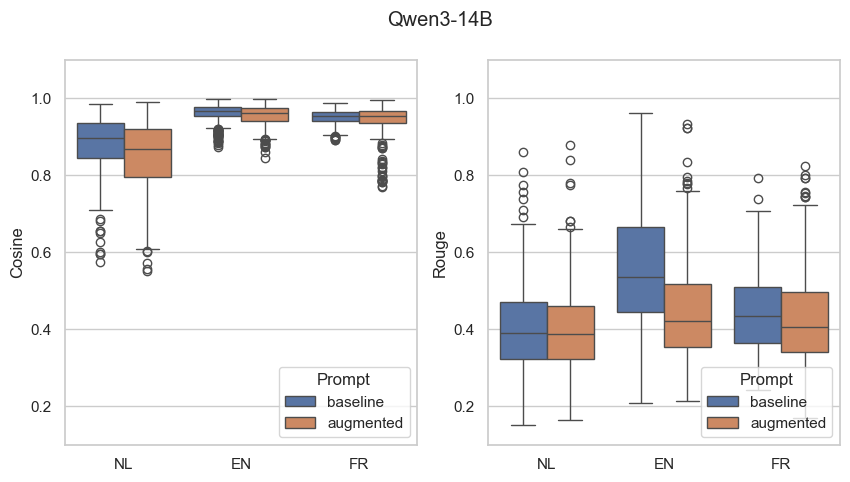

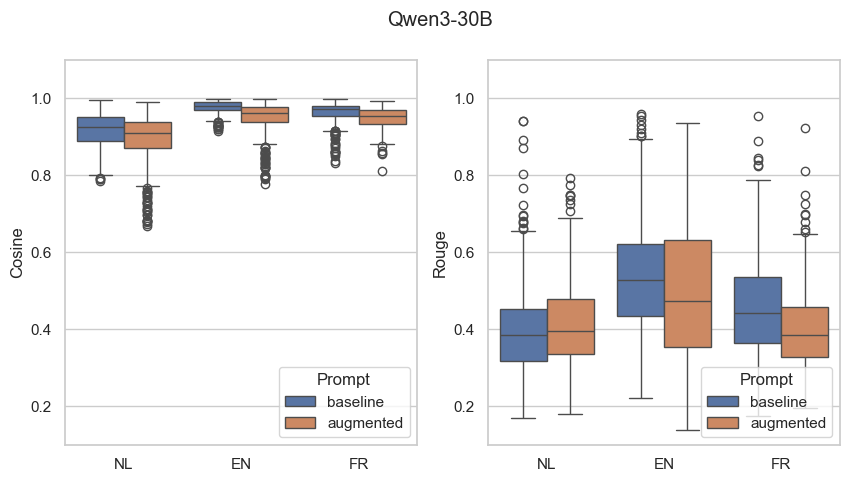

In [61]:
# std in scores amongst baseline answers and amongst augmented answers in a language per model
# same as above but not comparing between languages
for model in models:
    fig, axs = plt.subplots(ncols=len(metrics), figsize=(10,5), sharey=False)
    test = within_baseline_prompt[(within_baseline_prompt["Model"]==model)]
    plt.suptitle(model)
    test["Prompt"] = ["augmented" if x=="answers" else "baseline" for x in test["Answer"]]
    test = test.sort_values(by="Answer", ascending=False)
    for i in range(len(metrics)):
        axs[i].set_ylim([0.1,1.1])
        sns.boxplot(x=test["Language"].to_list(), y=metrics[i], hue="Prompt", data=test, ax=axs[i])
        sns.move_legend(axs[i], "lower right")
    
    plt.show()

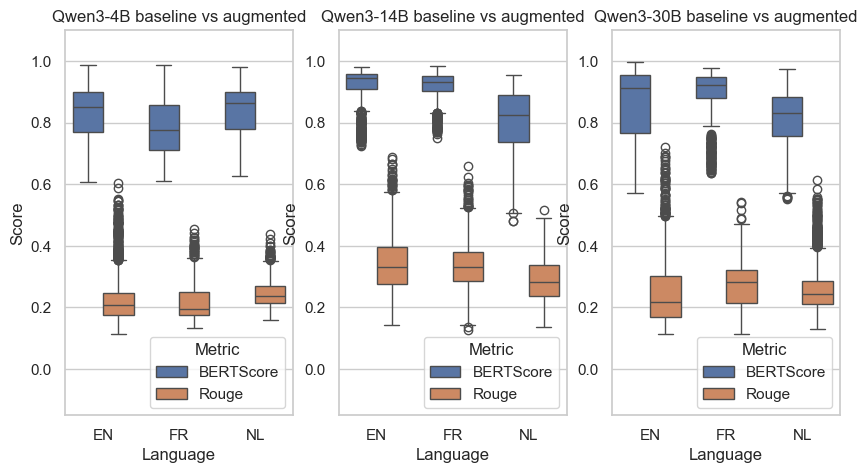

In [62]:
# std in scores between baseline condition and augmented condition per language per model

fig, axs = plt.subplots(ncols=len(models), figsize=(10,5), sharey=False)
i=0

for model in models:
    axs[i].set_title(model + " baseline vs augmented")
    test = baseline_compare[baseline_compare["Model"]==model]
    test = test.rename(columns={"Cosine": "BERTScore"})
    test = test.melt(id_vars=["Model", "Question", "Language"], value_vars=["BERTScore", "Rouge"],value_name="Score", var_name="Metric")
    ax = sns.boxplot(data=test, x="Language", y="Score", hue="Metric", ax=axs[i])
    sns.move_legend(ax, loc="lower right")
    axs[i].set_ylim([-0.15, 1.1])
    i+=1

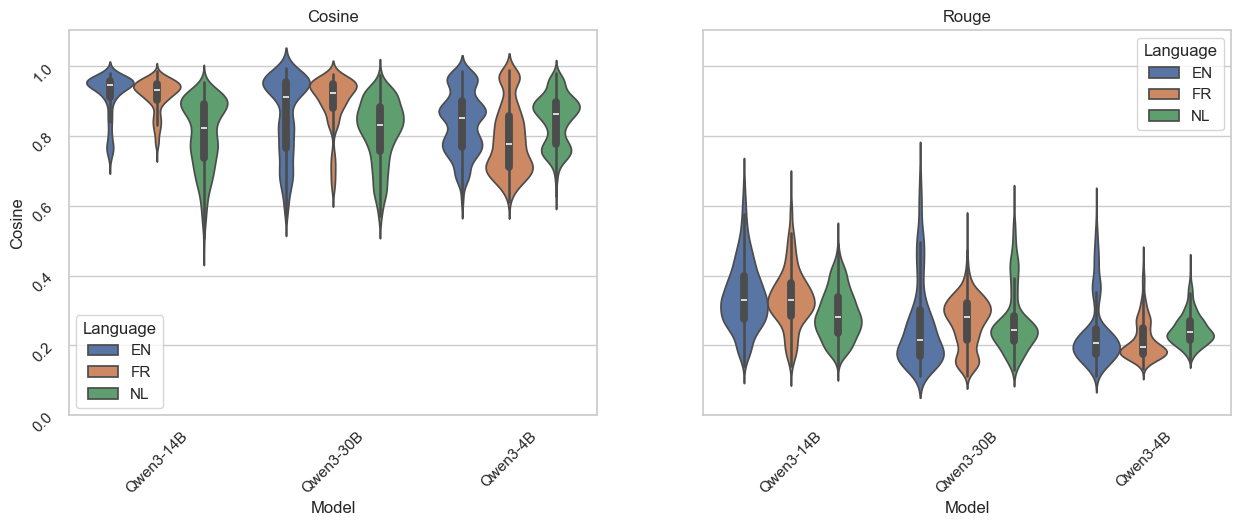

In [63]:
# violin plot of all questions, each subplot is one metric
# comparison of baseline1_lang_1 -> prompt1_lang_1, baseline1_lang_1 -> prompt2_lang1 and so on (agregate questions)
sns.set(style = 'whitegrid')  
ys = ["Cosine", "Rouge"]
fig, axs = plt.subplots(ncols=len(ys), figsize=(15,5), sharey=True)

# not between questions, each violin plot has 24 data points
for i in range(len(ys)):
    axs[i].tick_params(labelrotation=45)   
    axs[i].title.set_text(ys[i])
    sns.violinplot(x="Model", 
                       y=ys[i], 
                       hue="Language",
                       data=baseline_compare,
                       density_norm='count',
                       ax=axs[i])

# Visualization of reranked/retrieved docs?

In [64]:
from datasets import load_from_disk, concatenate_datasets
import glob
import pickle
import json
import re
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

In [65]:
paths = glob.glob("t0*")
answers = [load_from_disk(x) for x in paths]
answers = concatenate_datasets(answers)
with open("question_map.pkl", 'rb') as f:
    question_map = pickle.load(f)
with open("../params.json", 'r') as f:
    params = json.load(f)
answers = answers.add_column("question_mapped", [question_map[x] for x in answers["question"]])

In [66]:
answers = answers.to_pandas()

In [67]:
answers

,question,answers,baseline_answer,reranked_doc_ids,retrieved_doc_ids,language,model,question_mapped
0,Who was Napoleon Bonaparte?,[Napoleon Bonaparte was a French military lead...,[Napoleon Bonaparte was a French military and ...,"[american_stories957475, american_stories15622...","[blbooks1789933, american_stories733232, ameri...",EN,Qwen3-14B,Question 1
1,Was Napoleon Bonaparte a hero?,[Whether Napoleon Bonaparte was a hero is subj...,[Whether Napoleon Bonaparte was a hero depends...,"[american_stories1562206, blbooks1789933, amer...","[american_stories1562206, american_stories7332...",EN,Qwen3-14B,Question 2
2,Was Napoleon Bonaparte a tyrant?,"[Yes, Napoleon Bonaparte is described as a tyr...",[Whether Napoleon Bonaparte was a tyrant is a ...,"[blbooks1836403, american_stories1562206, amer...","[american_stories1562206, blbooks2049890, amer...",EN,Qwen3-14B,Question 3
3,Was Napoleon Bonaparte a villain?,[Whether Napoleon Bonaparte was a villain is s...,[Whether Napoleon Bonaparte was a villain depe...,"[american_stories1562206, american_stories1413...","[american_stories1562206, blbooks2049890, amer...",EN,Qwen3-14B,Question 4
4,How did Napoleon Bonaparte establish his empir...,[Napoleon Bonaparte established his empire in ...,[Napoleon Bonaparte established his empire in ...,"[blbooks1789933, american_stories957475, ameri...","[american_stories846451, american_stories13021...",EN,Qwen3-14B,Question 5
...,...,...,...,...,...,...,...,...
85,Hoe werd Napoleon Bonaparte keizer van Frankrijk?,[Napoleon Bonaparte werd keizer van Frankrijk ...,[Napoleon Bonaparte was niet keizer van Frankr...,"[delpher193521, delpher490407, delpher231516]","[dbnl2038, delpher177912, dbnl47531, dbnl70279...",NL,Qwen3-4B-Instruct-2507,Question 6
86,Werd Napoleon Bonaparte's aanspraak op keizers...,"[Nee, Napoleon Bonaparte's aanspraak op keizer...","[Nee, Napoleon Bonaparte's aanspraak op keizer...","[delpher490407, delpher205393, delpher193521]","[dbnl2038, delpher376126, delpher509910, dbnl7...",NL,Qwen3-4B-Instruct-2507,Question 7
87,Welke invloed had Napoleon Bonaparte's heersch...,[Napoleon Bonaparte’s heerschappij had een sig...,[Napoleon Bonapartes heerschappij had weinig d...,"[delpher555506, delpher115853, dbnl2038]","[dbnl2038, delpher468739, delpher122800, dbnl8...",NL,Qwen3-4B-Instruct-2507,Question 8
88,Wat was de impact van Napoleon Bonaparte op En...,[De impact van Napoleon Bonaparte op Engeland ...,"[Napoleon Bonaparte had een significante, maar...","[dbnl2038, dbnl70279, delpher231516]","[dbnl2038, delpher468739, dbnl65911, delpher12...",NL,Qwen3-4B-Instruct-2507,Question 9


Source      americanstories blbooks    bnfnewspaper dbnl delpher        
Language                 EN      EN FR           FR   NL      EN FR   NL
count count             149      35  3          195   80      16  2  120

Source      americanstories blbooks bnfnewspaper dbnl delpher    
Language                 EN      EN           FR   NL      EN  NL
count count              21       7           30   11       2  19
Source      americanstories blbooks    bnfnewspaper dbnl delpher        
Language                 EN      EN FR           FR   NL      EN FR   NL
count count             149      35  3          195   80      16  2  120

Source      americanstories blbooks bnfnewspaper dbnl delpher    
Language                 EN      EN           FR   NL      EN  NL
count count              21       7           30   11       2  19

Source      americanstories blbooks    bnfnewspaper dbnl delpher        
Language                 EN      EN FR           FR   NL      EN FR   NL
count count      

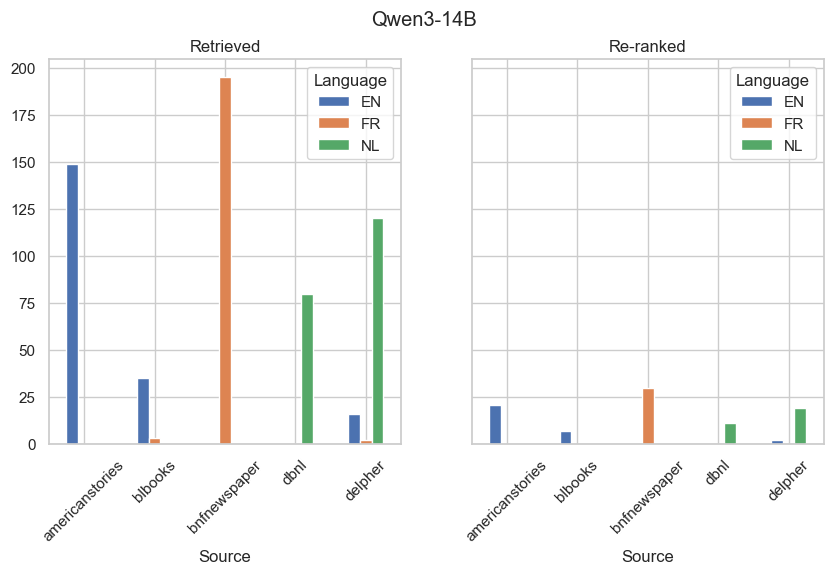

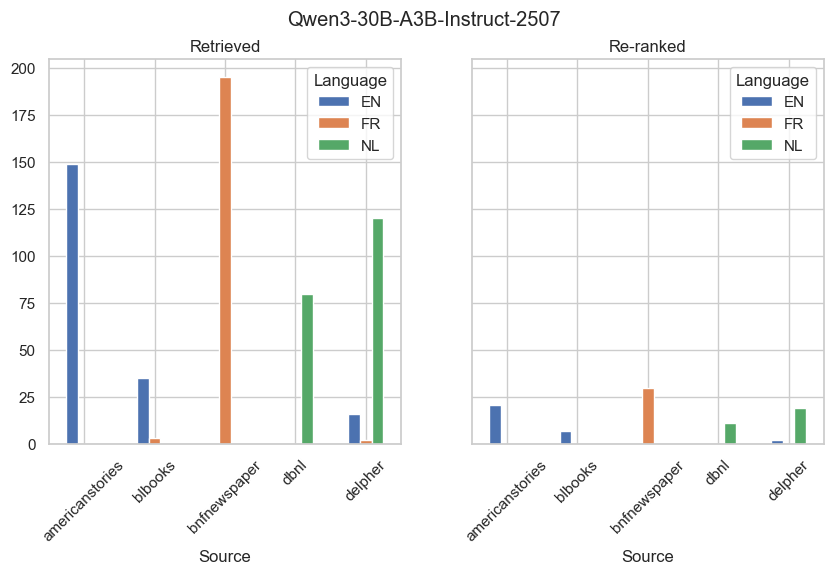

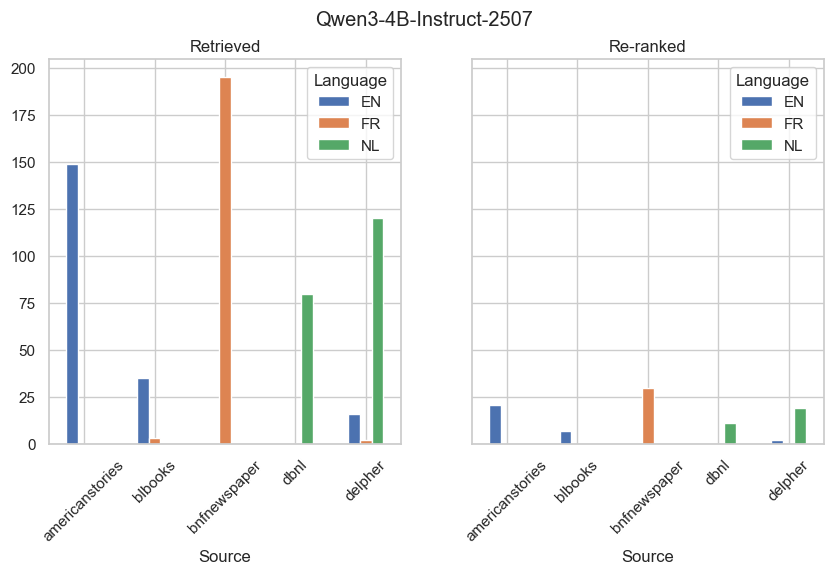

In [68]:
for model in answers["model"].unique():
    fig, axs = plt.subplots(ncols=2, figsize=(10,5), sharey=True)
    plt.xticks(rotation=45)
    plt.suptitle(model)
    c=0
    for i in ["retrieved_doc_ids", "reranked_doc_ids"]:
        axs[c].set_title("Retrieved" if "retrieved" in i else "Re-ranked")
        subset = answers[(answers["model"]==model)][[i, "language"]]
        sources = []
        language = []
        for _, j in subset.iterrows():
            sources.extend([re.sub('[^a-zA-Z]+', '', s) for s in j[i]])
            language.extend([j["language"]]*len(j[i]))
        df = pd.DataFrame({"Source":sources, "Language": language}) 
        df.value_counts().unstack().plot(kind="bar", ax=axs[c])
        df["count"] = 1
        print(df.groupby(["Source", "Language"]).agg(["count"]).transpose())
        print()
        axs[c].tick_params(axis='x', labelrotation=45)
        c+=1